# Complement · La recta i el pendent

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/LaRecta.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Interpretar pendent, ordenada a l'origen i rectes verticals.

**Abans de començar:** coordenades cartesianes  
**Temps orientatiu:** 1 sessió. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de LaRecta.ipynb, amb controls en lloc d'un vídeo dependent de FFmpeg.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Si canviem la mida del triangle de pendent, canvia la pendent de la recta?

**Al final ho has de poder explicar:** Interpretar la pendent com una proporció amb signe i unitats, no com una inclinació aparent a la pantalla.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## Rectes no verticals
$y=mx+b$ representa una recta no vertical. m és el pendent i b és l'ordenada
a l'origen; el punt de tall amb l'eix vertical és $(0,b)$.
Si m≠0, és una funció polinòmica de primer grau. Si m=0, és constant.
Les rectes verticals $x=c$ no són gràfiques d'una funció $y=f(x)$.

Prediu l'efecte de canviar m mantenint b fix. Després fes el contrari.


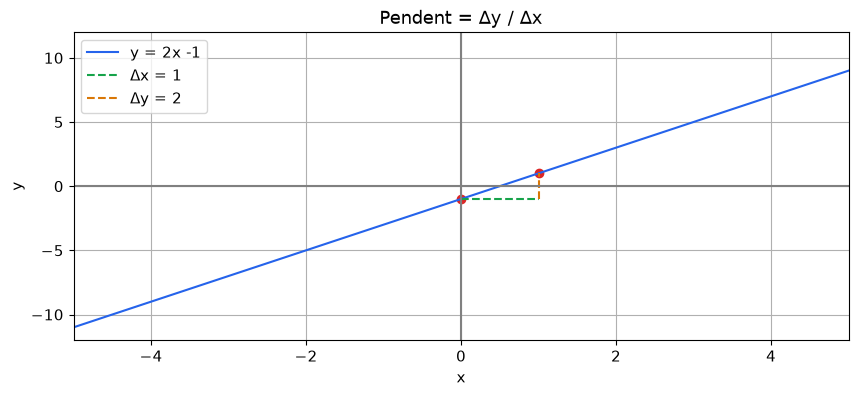

interactive(children=(FloatSlider(value=2.0, description='pendent', max=5.0, min=-5.0, step=0.25), FloatSlider…

In [2]:
def recta(pendent=2.0, ordenada=-1.0):
    x = np.linspace(-5, 5, 200)
    fig, ax = plt.subplots()
    ax.plot(x, pendent*x+ordenada, color="#2563eb", label=f"y = {pendent:g}x {ordenada:+g}")
    ax.plot([0, 1], [ordenada, ordenada], "--", color="#16a34a", label="Δx = 1")
    ax.plot([1, 1], [ordenada, ordenada+pendent], "--", color="#d97706", label=f"Δy = {pendent:g}")
    ax.scatter([0, 1], [ordenada, ordenada+pendent], color="#dc2626")
    ax.axhline(0, color="0.5"); ax.axvline(0, color="0.5")
    ax.set(xlim=(-5, 5), ylim=(-12, 12), xlabel="x", ylabel="y", title="Pendent = Δy / Δx")
    ax.legend(); plt.show()
panell = explora(recta, pendent=(-5., 5., .25), ordenada=(-5., 5., .5))


In [3]:
def pendent_dos_punts(a, b):
    if a[0] == b[0]:
        raise ValueError("No hi ha pendent finit: punts amb la mateixa abscissa.")
    return (b[1]-a[1])/(b[0]-a[0])
print("Pendent entre (1,1) i (7,4):", pendent_dos_punts((1,1), (7,4)))


Pendent entre (1,1) i (7,4): 0.5


## Laboratori animat · observa, atura i explica


### Una rampa, dos triangles, una mateixa proporció

Una rampa puja 2 m per cada 3 m de recorregut horitzontal. La pendent és
$m=\Delta y/\Delta x=2/3$. Un triangle amb base 6 m té altura 4 m: $4/6=2/3$.
**La proporció es conserva encara que triem dos punts més allunyats.**

A l'animació, l'ordenada a l'origen es manté en $b=1$ i canviem m.
La recta sempre passa per (0,1). Blau: triangle de base 1. Taronja: triangle de base 2.
Si m és negativa, l'increment vertical també és negatiu: ens desplacem cap avall.

El gràfic dret representa $\Delta y=m\Delta x$: quan dupliquem $\Delta x$, també
dupliquem $\Delta y$. El punt de tall b no intervé en aquesta proporció.

**Prediu.** Amb m=−1,5 i b=1, quina és y quan x=2? **Pausa** a m=0: què tenen d'especial
els triangles? Una recta vertical, en canvi, té $\Delta x=0$ i no té pendent finita.


In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [5]:
titol_laboratori = "Pendent: canvi vertical dividit pel canvi horitzontal"
fotogrames_laboratori = list(range(17))

def dades_rampa(m, dx, b=1):
    return m*dx, b+m*dx

def dibuixa_laboratori(pas, axes):
    m = -2+pas/4
    ax, bx = axes
    x = np.linspace(-1, 3, 200)
    ax.plot(x, m*x+1, color="#7c3aed", lw=2)
    for dx, color in [(1, "#2563eb"), (2, "#ea580c")]:
        dy, y = dades_rampa(m, dx)
        ax.plot([0, dx, dx], [1, 1, y], color=color, lw=2, label=f"Δx={dx}; Δy={dy:g}")
        ax.scatter([dx], [y], color=color, s=50)
    ax.scatter([0], [1], color="0.2", s=55, zorder=5)
    ax.set(xlim=(-.5, 2.5), ylim=(-4, 6), xlabel="x", ylabel="y", title=f"y = {m:g}x + 1\nTotes passen per (0,1)")
    ax.legend(fontsize=8, loc="upper left")
    dx = np.linspace(0, 3, 100)
    bx.plot(dx, m*dx, color="#047857")
    bx.scatter([1, 2], [m, 2*m], color=["#2563eb", "#ea580c"], s=60)
    bx.axhline(0, color="0.5", lw=.7)
    bx.set(xlim=(0, 3), ylim=(-6.5, 6.5), xlabel="Δx", ylabel="Δy",
           title=f"Proporció constant: Δy / Δx = {m:g}\nLa pendent conserva el signe")


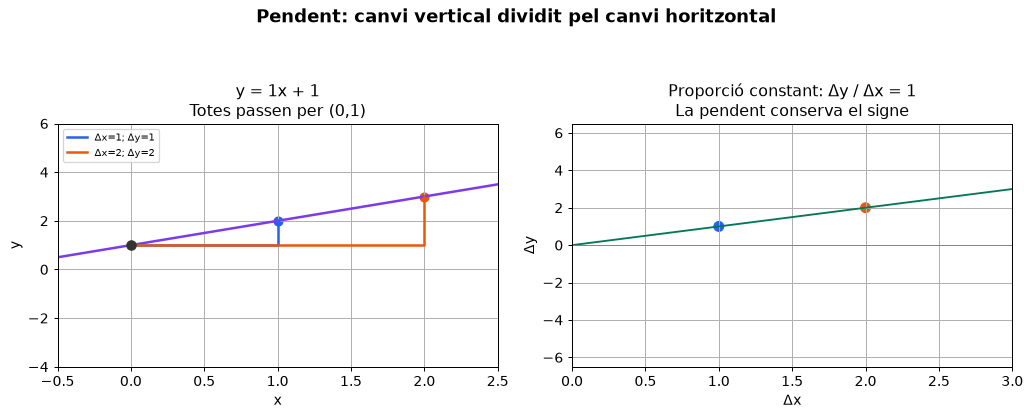

In [6]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(12)


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [7]:
display(anima_laboratori())


### Compara abans de concloure

Compara m=−1 i m=1 amb la mateixa ordenada b=1. Què es conserva? Què canvia de signe? Després tria m=0 i explica per què és un cas diferent d'una recta vertical.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [8]:
parella_comparacio = (4, 12)
etiquetes_comparacio = [f"Pendent m = {-2+k/4:g}" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'Si Δx=3 i Δy=−6, quina és la pendent?', 'opcions': ['−2', '−1/2', '2'], 'correcta': 0, 'retorn': ['Correcte: m=Δy/Δx=−6/3=−2.', "Has invertit el quocient: la pendent és canvi vertical dividit per l'horitzontal.", 'El signe negatiu indica que y disminueix quan x augmenta.']}, {'enunciat': 'A P=1,5d+3, què significa el 3?', 'opcions': ['Tres quilòmetres', 'Un cost inicial de 3 euros', 'La pendent'], 'correcta': 1, 'retorn': ['d és la distància; el terme constant té les unitats de P, euros.', 'Correcte: és el preu quan d=0.', "La pendent és 1,5 €/km; 3 és l'ordenada a l'origen."]}, {'enunciat': 'Dues rectes amb pendent igual i ordenades diferents...', 'opcions': ["Sempre es tallen a l'origen", 'Coincideixen', 'Són paral·leles i no es tallen'], 'correcta': 2, 'retorn': ["Tenen punts de tall amb l'eix y diferents i mantenen la mateixa direcció.", 'Per coincidir necessitarien també la mateixa ordenada.', 'Correcte: la diferència vertical entre elles és constant i no nul·la.']}]


In [9]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


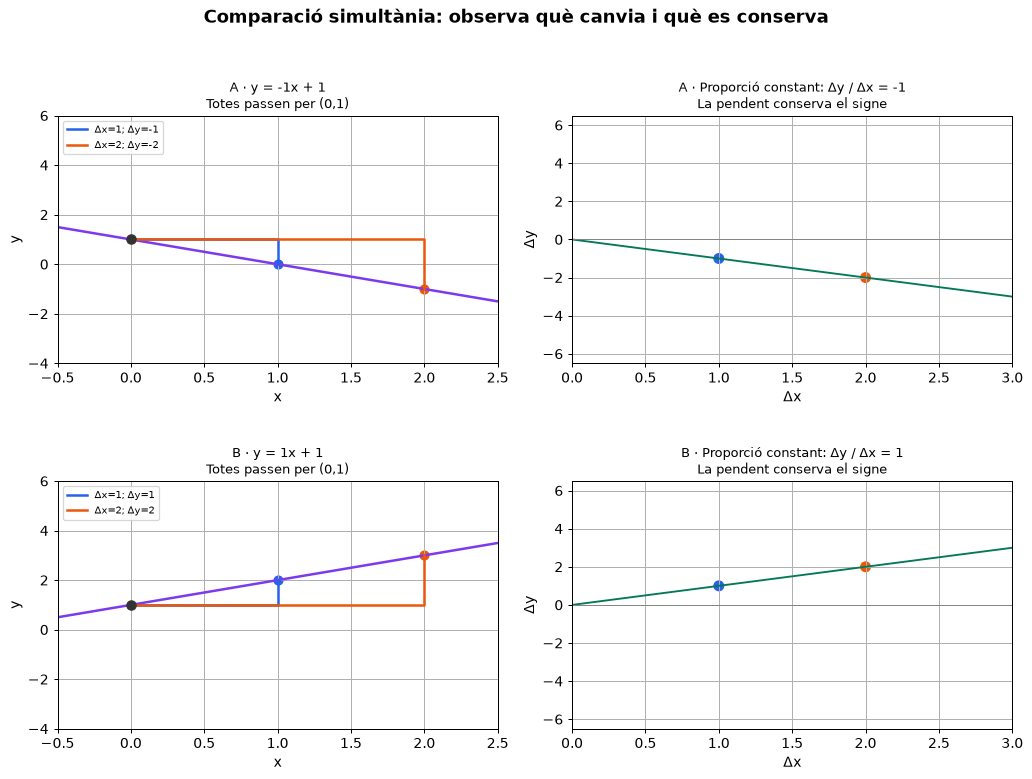

interactive(children=(Dropdown(description='Estat A:', index=4, options=(('Pendent m = -2', 0), ('Pendent m = …

In [10]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Dues tarifes: A cobra 3 € inicials i 1,50 €/km; B no té cost inicial i cobra 2 €/km. Prediu quan convé cadascuna i troba el punt de tall amb una equació, abans de mirar-lo al gràfic.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


Solució de l'equació: d=6 km; preu=12 €


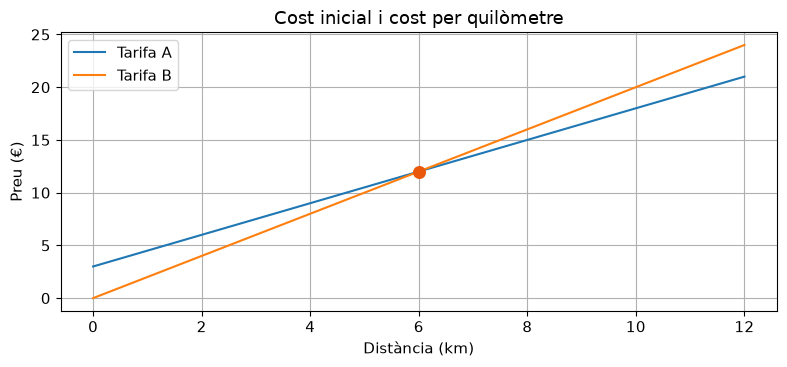

In [11]:
inici_A, preu_A = 3.0, 1.5
inici_B, preu_B = 0.0, 2.0
distancia = np.linspace(0, 12, 121)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(distancia, inici_A+preu_A*distancia, label="Tarifa A")
ax.plot(distancia, inici_B+preu_B*distancia, label="Tarifa B")
if preu_A != preu_B:
    tall = (inici_B-inici_A)/(preu_A-preu_B)
    print(f"Solució de l'equació: d={tall:g} km; preu={inici_A+preu_A*tall:g} €")
    if 0 <= tall <= 12:
        ax.scatter(tall, inici_A+preu_A*tall, color="#ea580c", s=70, zorder=5)
elif inici_A == inici_B:
    print("Les dues tarifes coincideixen.")
else:
    print("Les rectes són paral·leles: no tenen punt de tall.")
ax.set(xlabel="Distància (km)", ylabel="Preu (€)", title="Cost inicial i cost per quilòmetre")
ax.legend(); plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Si Δx=3 i Δy=−6, quina és la pendent?**

- A. −2
- B. −1/2
- C. 2

**2. A P=1,5d+3, què significa el 3?**

- A. Tres quilòmetres
- B. Un cost inicial de 3 euros
- C. La pendent

**3. Dues rectes amb pendent igual i ordenades diferents...**

- A. Sempre es tallen a l'origen
- B. Coincideixen
- C. Són paral·leles i no es tallen

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [12]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Una recta passa per (2,5) i (6,3). Calcula m, després b i comprova l'equació amb els dos punts.
2. Un taxi cobra 3 € inicials i 1,50 €/km. Escriu l'equació, les unitats de m i b i el preu de 4 km.
3. Dues rectes tenen la mateixa pendent però ordenades diferents: què tenen en comú? Es tallen?
4. Per què una recta vertical no es pot escriure en la forma $y=mx+b$ amb m finit?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [13]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

m=−1/2 i b=6, de manera que y=−x/2+6. El taxi segueix P=1,5d+3:
m té unitats €/km i b euros; per a 4 km són 9 €. Les rectes amb pendent igual i ordenades
diferents són paral·leles. En una vertical, Δx=0 i dividir Δy per Δx no està definit.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## Activitats
1. Troba una recta que passi per (0,3) amb pendent −2.
2. Què representa una recta de pendent zero? I la recta x=2?
3. Comprova que la recta entre (1,1) i (7,4) té pendent 1/2.
4. Què necessitarem si el pendent canvia d'un punt a un altre d'una corba?

<details><summary>Comprovació</summary>

$y=-2x+3$. El pendent zero dona una funció constant; x=2 és una recta vertical,
no una funció de x. Per a una corba introduirem la derivada al quadern 08.
</details>


**Navegació:** [Índex i guia](README.md) · [Següent](Derivades_BAT.ipynb)
